#### Diwali Sales Data Analysis Using Python

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns

In [4]:
# Load data set
df = pd.read_csv("Diwali Sales Data.csv", encoding='unicode_escape')
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [5]:
# no. of rows and columns in data set
df.shape

(11251, 15)

In [6]:
# column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [12]:
# missing values
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [8]:
# drop unused column Status and unnamed1
df.drop(['Status','unnamed1'] , axis=1 , inplace=True)

In [11]:
# drop null values
df.dropna(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


In [15]:
# change data types of amount float to int 
df['Amount'] =  df['Amount'].astype('int')

In [17]:
df['Amount'].dtypes

dtype('int64')

In [19]:
# statistical summary of numerical columns 
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [20]:
# use describe for specific column
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


#### EDA Analysis

In [21]:
# Gender column
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

Text(0, 0.5, 'Count')

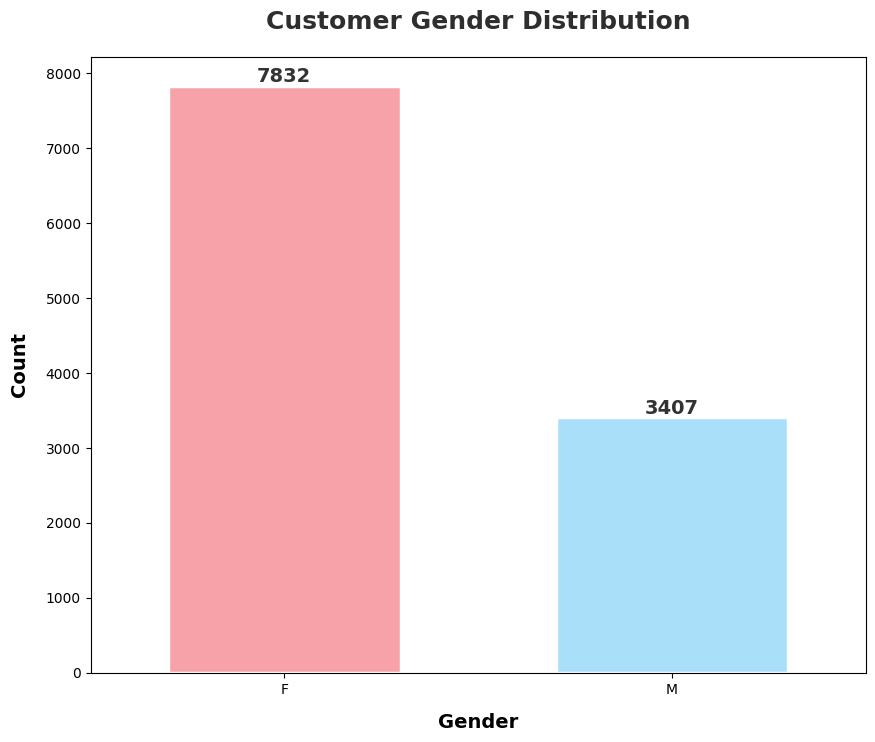

In [144]:
plt.figure(figsize=(10, 8))

# Create countplot with stylish parameters
ax = sns.countplot(x='Gender', 
                   data=df,
                   palette=['#FF9AA2', '#A2E1FF'],  
                   hue='Gender',
                   saturation=0.85,
                   width=0.6,
                   edgecolor='white',
                   linewidth=2.5)

# Customize bar labels with elegant formatting
for bars in ax.containers:
    ax.bar_label(bars, 
                 label_type='edge',
                 fontsize=14,
                 fontweight='semibold',
                 color='#333333')  


plt.title('Customer Gender Distribution',
          fontsize=18,
          pad=20,
          fontweight='bold',
          color='#2e2e2e')

plt.xlabel('Gender',
           fontsize=14,
           labelpad=12,
           fontweight='semibold')

plt.ylabel('Count',
           fontsize=14,
           labelpad=12,
           fontweight='semibold')

In [28]:
df.groupby('Gender')[['Amount']].sum()

,Amount
Gender,
F,74335853
M,31913276


Text(0, 0.5, 'Total Sales Amount')

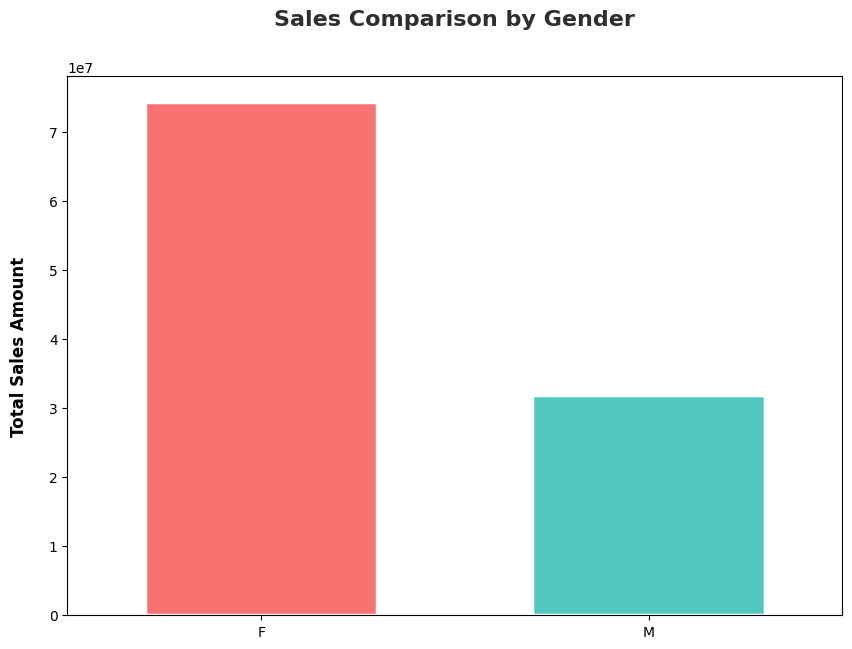

In [145]:
sales_gen = df.groupby('Gender')[['Amount']].sum().reset_index().sort_values('Amount', ascending=False)

# Create styled plot
plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Gender', 
                 y='Amount', 
                 hue='Gender',
                 data=sales_gen,
                 palette=['#FF6B6B', '#4ECDC4'], 
                 saturation=0.9,
                 width=0.6,
                 edgecolor='white',
                 linewidth=2.5)

plt.title("Sales Comparison by Gender\n", 
          fontsize=16,
          pad=20,
          fontweight='bold',
          color='#2e2e2e')

plt.xlabel("", fontsize=12)  # Empty for cleaner look
plt.ylabel("Total Sales Amount", 
           fontsize=12,
           labelpad=15,
           fontweight='semibold')

In [ ]:
# conclusion
# From above analysis, we can see that most of the buyers are female and even the 
# purchasing power of females are greater than men

##### Age column

Text(0, 0.5, 'Count')

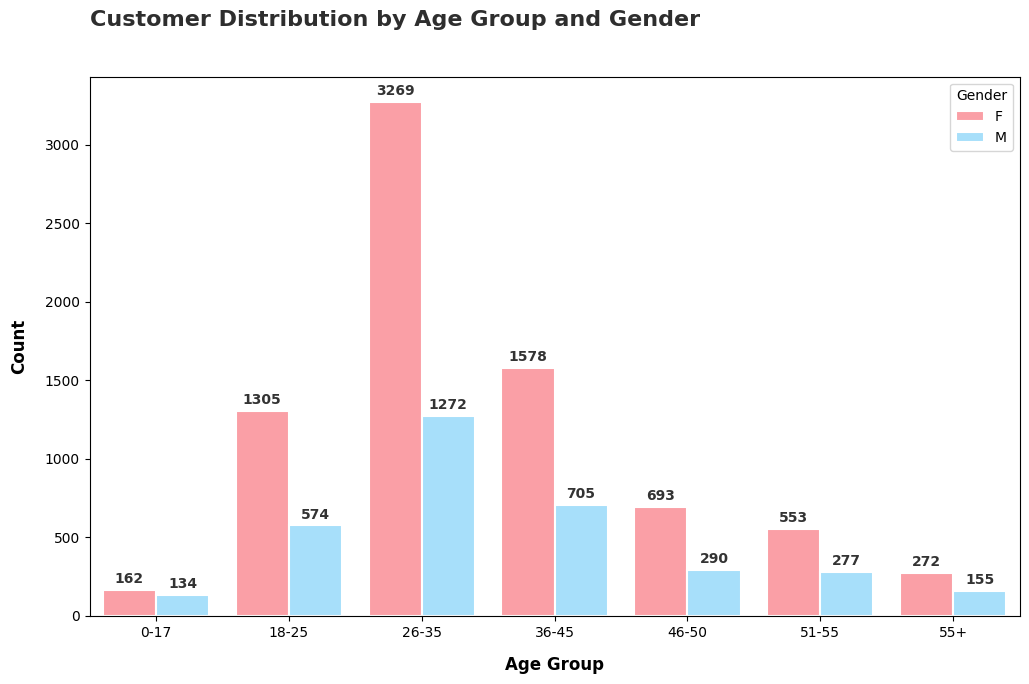

In [148]:
plt.figure(figsize=(12, 7))

# Create the countplot with proper hue handling
ax = sns.countplot(data=df, 
                   x='Age Group',
                   hue='Gender',
                   palette=['#FF9AA2', '#A2E1FF'],  
                   order=sorted(df['Age Group'].unique()),  
                   saturation=0.9,
                   edgecolor='white',
                   linewidth=1.5)

# Customize bar labels with improved formatting
for bars in ax.containers:
    ax.bar_label(bars, 
                 label_type='edge',
                 fontsize=10,
                 fontweight='semibold',
                 color='#333333',
                 padding=3)

# Enhanced title and labels
plt.title('Customer Distribution by Age Group and Gender\n',
          fontsize=16,
          pad=20,
          fontweight='bold',
          color='#2e2e2e',
          loc='left')

plt.xlabel('Age Group',
           fontsize=12,
           labelpad=12,
           fontweight='semibold')
plt.ylabel('Count',
           fontsize=12,
           labelpad=12,
           fontweight='semibold')

Text(0, 0.5, 'Sales Amount')

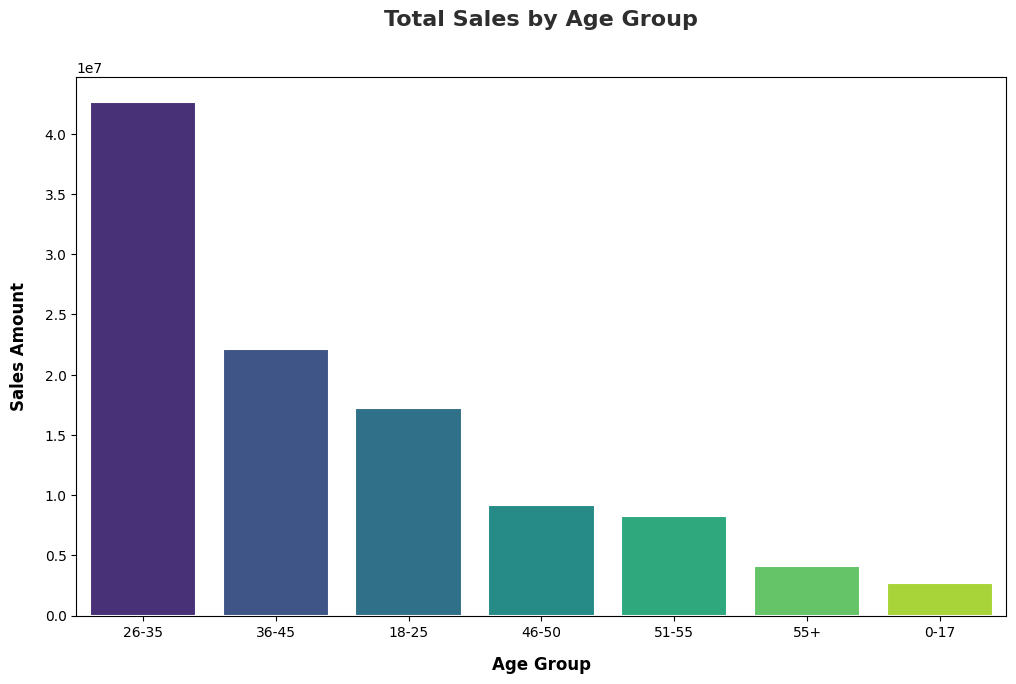

In [150]:
sales_age = df.groupby('Age Group')['Amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Age Group', 
                 y='Amount', 
                 data=sales_age,
                 hue='Age Group',  
                 palette='viridis',  
                 saturation=0.9,
                 width=0.8,
                 edgecolor='white',
                 linewidth=1.5)

plt.title('Total Sales by Age Group\n', 
          fontsize=16,
          pad=20,
          fontweight='bold',
          color='#2e2e2e')

plt.xlabel("Age Group", 
           fontsize=12,
           labelpad=12,
           fontweight='semibold')
plt.ylabel("Sales Amount", 
           fontsize=12,
           labelpad=12,
           fontweight='semibold')

In [ ]:
'''
From the above Analysis we see that most of the buyers are of the age group b/w 26-35 
yrs female
'''

##### State Column

In [64]:
df.groupby('State')[['Orders']].sum()

,Orders
State,
Andhra Pradesh,2051
Bihar,1062
Delhi,2740
Gujarat,1066
Haryana,1109
Himachal Pradesh,1568
Jharkhand,953
Karnataka,3240
Kerala,1137


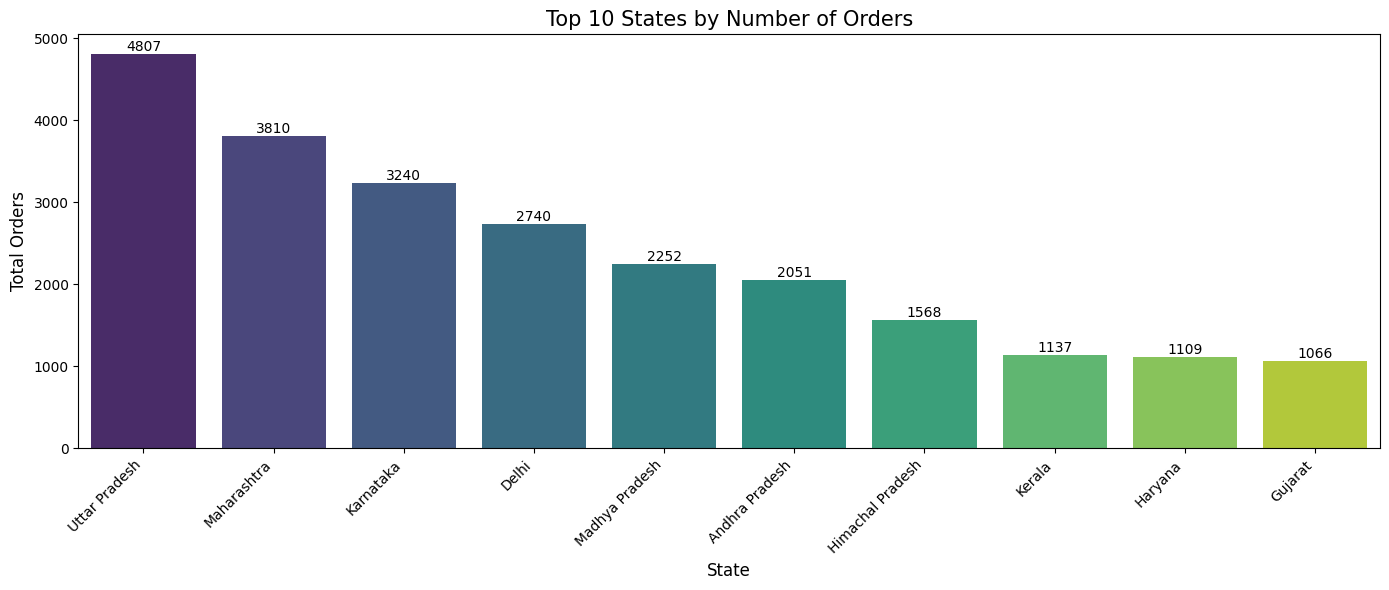

In [72]:
# total no of orders from top 10 states
sales_state = df.groupby('State')[['Orders']].sum().sort_values(by='Orders' ,ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=sales_state, x='State', y='Orders', hue='State' ,palette='viridis')

# Add data labels on each bar
for bars in ax.containers:
    ax.bar_label(bars)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add titles and adjust layout
plt.title('Top 10 States by Number of Orders', fontsize=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.tight_layout()
plt.show()

In [76]:
df.groupby('State')[['Amount']].sum()

,Amount
State,
Andhra Pradesh,8037146
Bihar,4022757
Delhi,11603818
Gujarat,3946082
Haryana,4220175
Himachal Pradesh,4963368
Jharkhand,3026456
Karnataka,13523540
Kerala,3894491


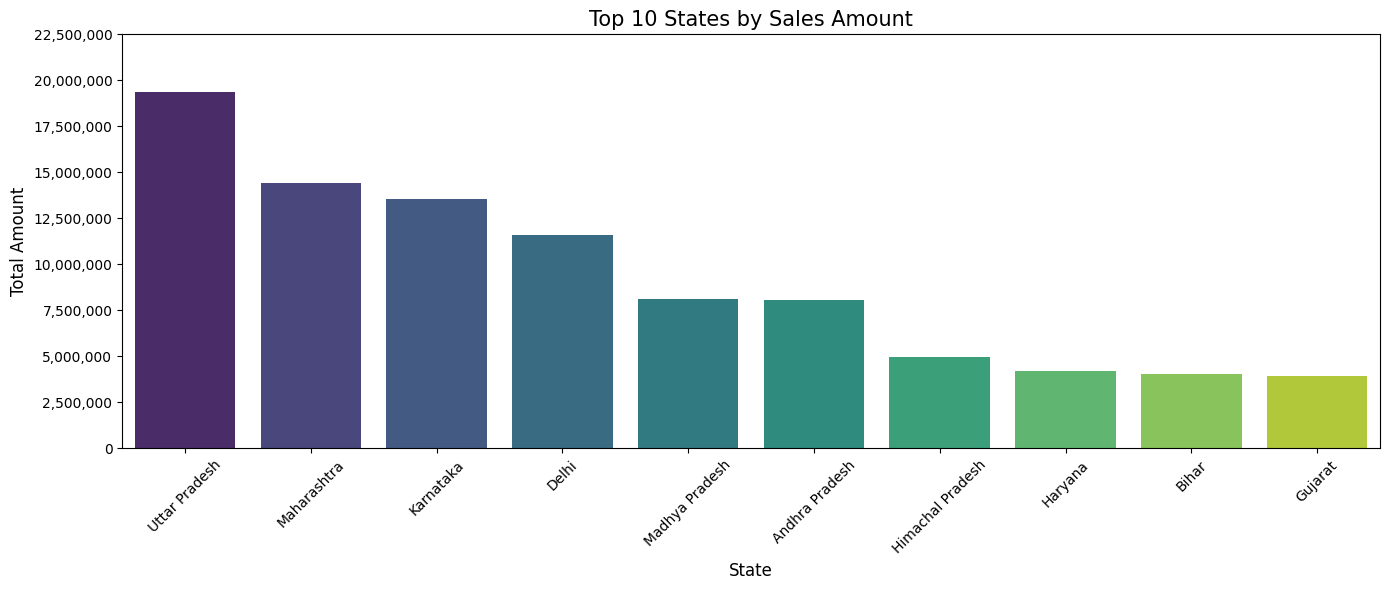

In [84]:
# Group and sort the data
sales_state = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=sales_state, x='State', y='Amount', hue='State', palette='viridis')


# Fix y-axis ticks to show actual values
plt.yticks(ticks=ax.get_yticks(), labels=[f'{int(x):,}' for x in ax.get_yticks()])

plt.xticks(rotation=45)
plt.title('Top 10 States by Sales Amount', fontsize=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Amount', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
'''
From above Analysis, we can see that most of the orders are from Uttar Pardesh, 
Maharashtra and Karnataka respectively by sales/amount is from UP, Karnataka and then
Maharashtra
'''

#### Marital Status

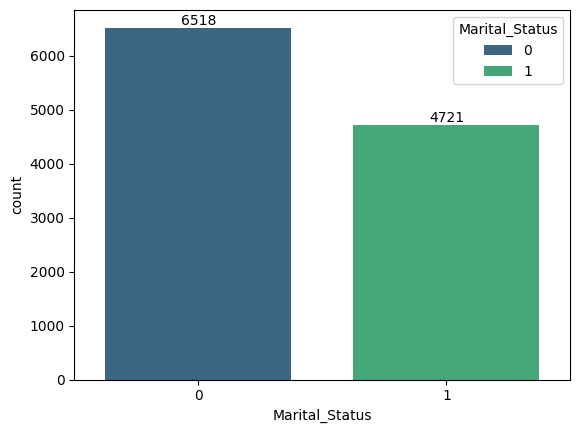

<Figure size 800x500 with 0 Axes>

In [94]:
ax = sns.countplot(data=df  ,width=0.75, x = 'Marital_Status', hue='Marital_Status' ,palette='viridis')
plt.figure(figsize=(8, 5))

for bars in ax.containers:
    ax.bar_label(bars)

Text(0, 0.5, 'Total Sales Amount')

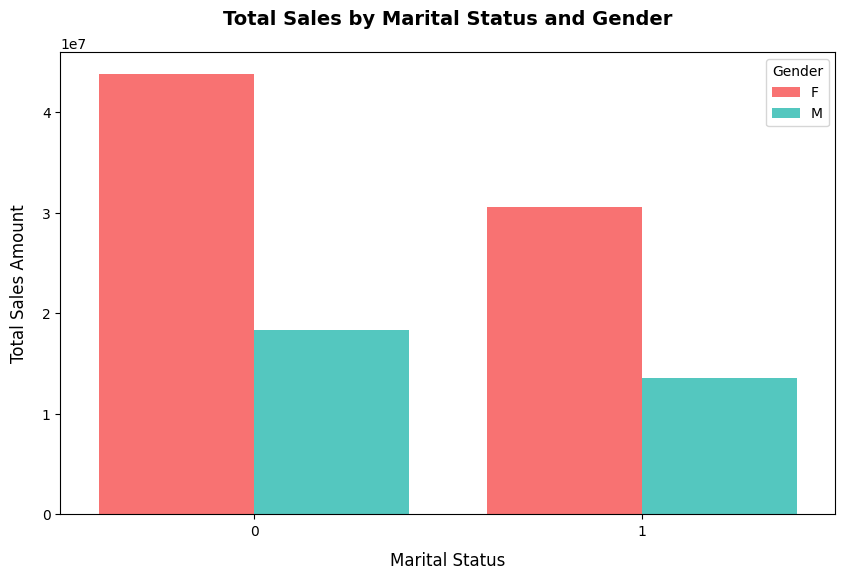

In [103]:
sales_state = df.groupby(['Marital_Status', 'Gender'])[['Amount']].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=sales_state, 
                 x='Marital_Status', 
                 y='Amount', 
                 hue='Gender',
                 palette=['#FF6B6B', '#4ECDC4'], 
                 saturation=0.9)
plt.title('Total Sales by Marital Status and Gender', 
          fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Marital Status', fontsize=12, labelpad=10)
plt.ylabel('Total Sales Amount', fontsize=12, labelpad=10)



In [ ]:
'''
From the above analysis, we can see that most of the buyers are married (women)
and they have high purchasing power
'''

#### Occupation

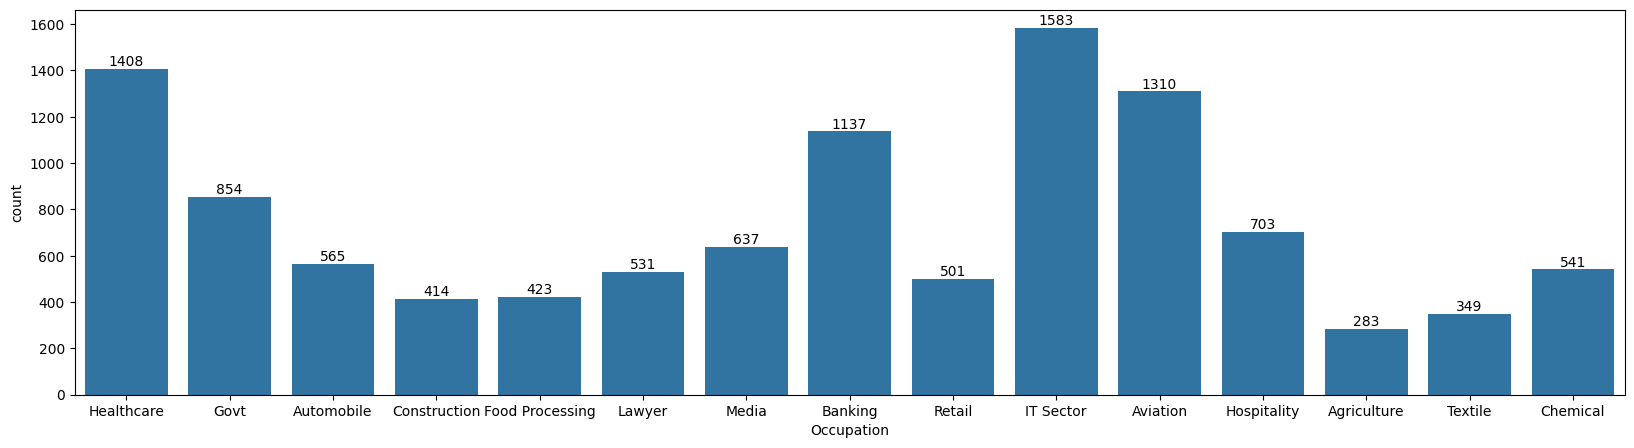

In [104]:
plt.figure(figsize=(20, 5))
ax = sns.countplot(data=df , x='Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

Text(0, 0.5, 'Count')

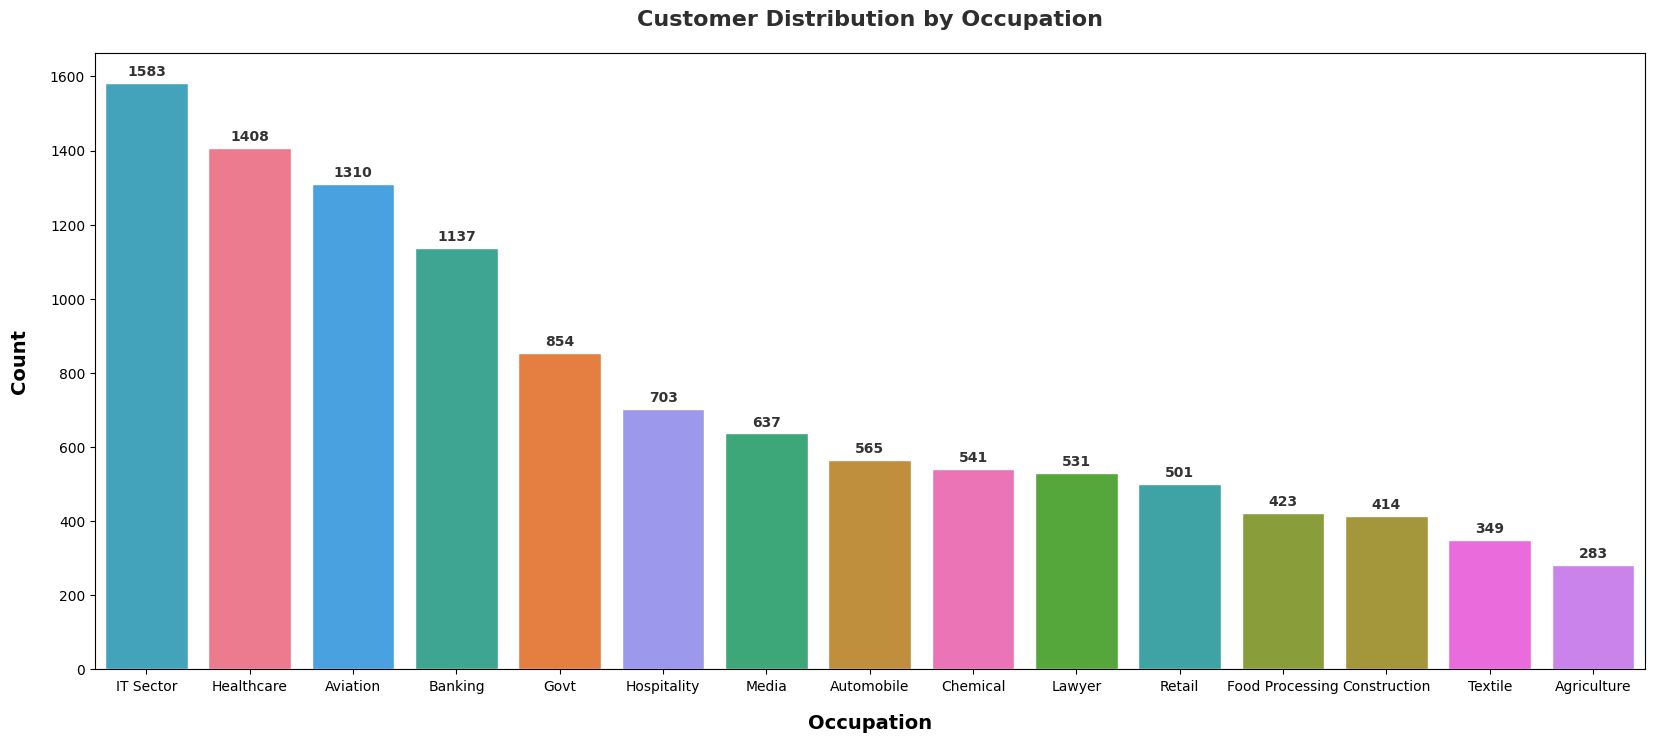

In [120]:
# Custom color palette - using a professional, accessible palette
occupation_palette = sns.color_palette("husl", n_colors=len(df['Occupation'].unique()))

plt.figure(figsize=(20, 8))
ax = sns.countplot(data=df, 
                   x='Occupation',
                   order=df['Occupation'].value_counts().index,  
                   hue='Occupation',
                   palette=occupation_palette,
                   saturation=0.85,
                   edgecolor='white',
                   linewidth=1)

# Customize bar labels
for bars in ax.containers:
    ax.bar_label(bars, 
                 label_type='edge',
                 fontsize=10,
                 padding=3,
                 color='#333333',
                 fontweight='semibold')

# Styling enhancements
plt.title('Customer Distribution by Occupation', 
          fontsize=16, pad=20, fontweight='bold', color='#2e2e2e')
plt.xlabel('Occupation', fontsize=14, labelpad=15, fontweight='semibold')
plt.ylabel('Count', fontsize=14, labelpad=15, fontweight='semibold')

Text(0, 0.5, 'Sales Amount')

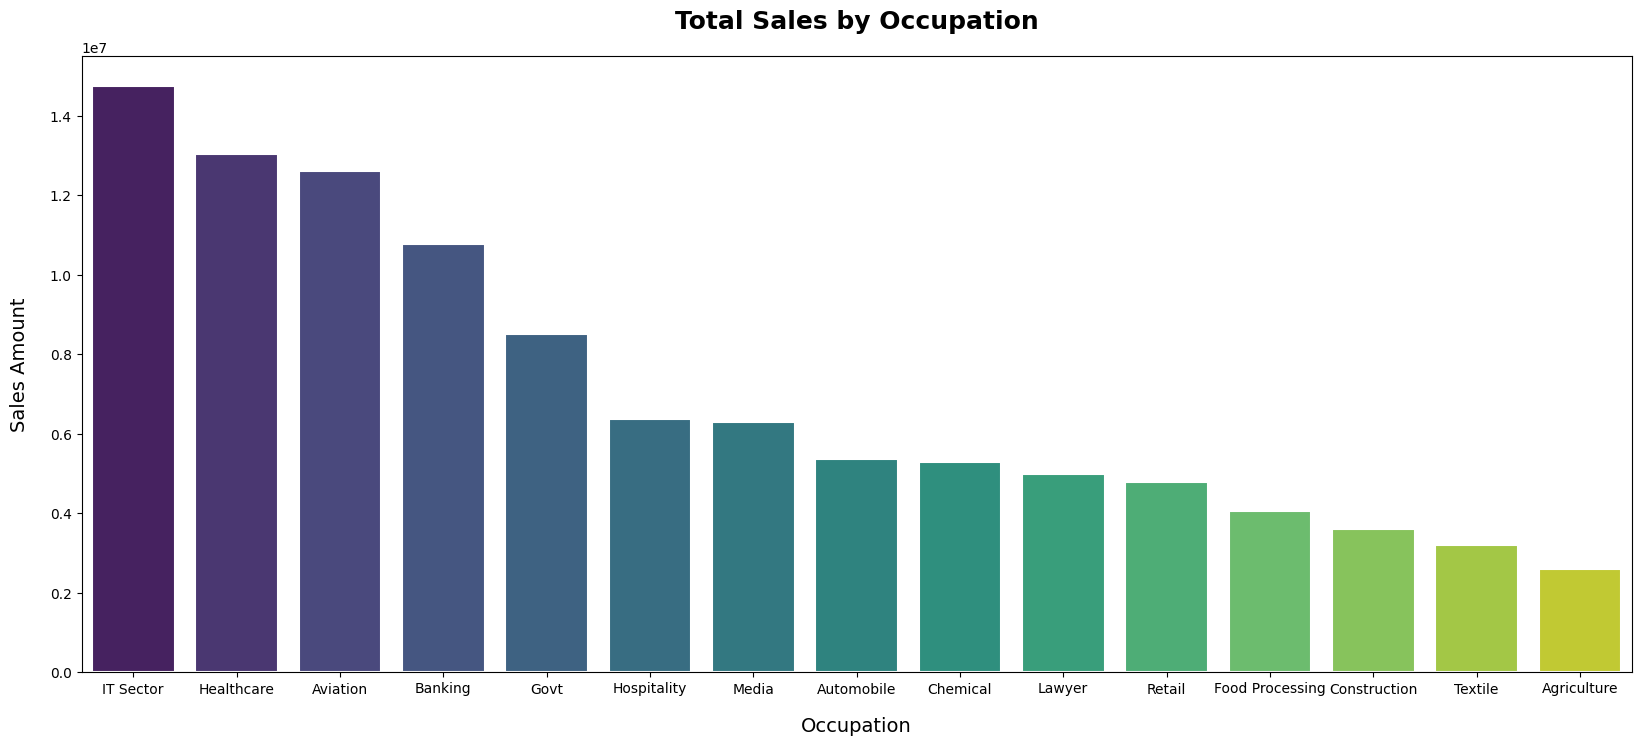

In [118]:
sales_state = df.groupby(['Occupation'])[['Amount']].sum().sort_values(by='Amount', ascending=False)
plt.figure(figsize=(20, 8))
palette = sns.color_palette("viridis", len(sales_state))
sns.barplot(
    data=sales_state , x='Occupation', y='Amount',
    hue='Occupation',
    palette=palette,
    edgecolor='white',
    linewidth=1.5
    )

plt.title('Total Sales by Occupation', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Occupation', fontsize=14, labelpad=15)
plt.ylabel('Sales Amount', fontsize=14, labelpad=15)

In [ ]:
'''
From the above analysis on Occupation, we can see that most of the buyers/customers are
working in IT, Healthcare and Aviation
'''

#### Product Categoty

Text(0, 0.5, 'Purchase Count')

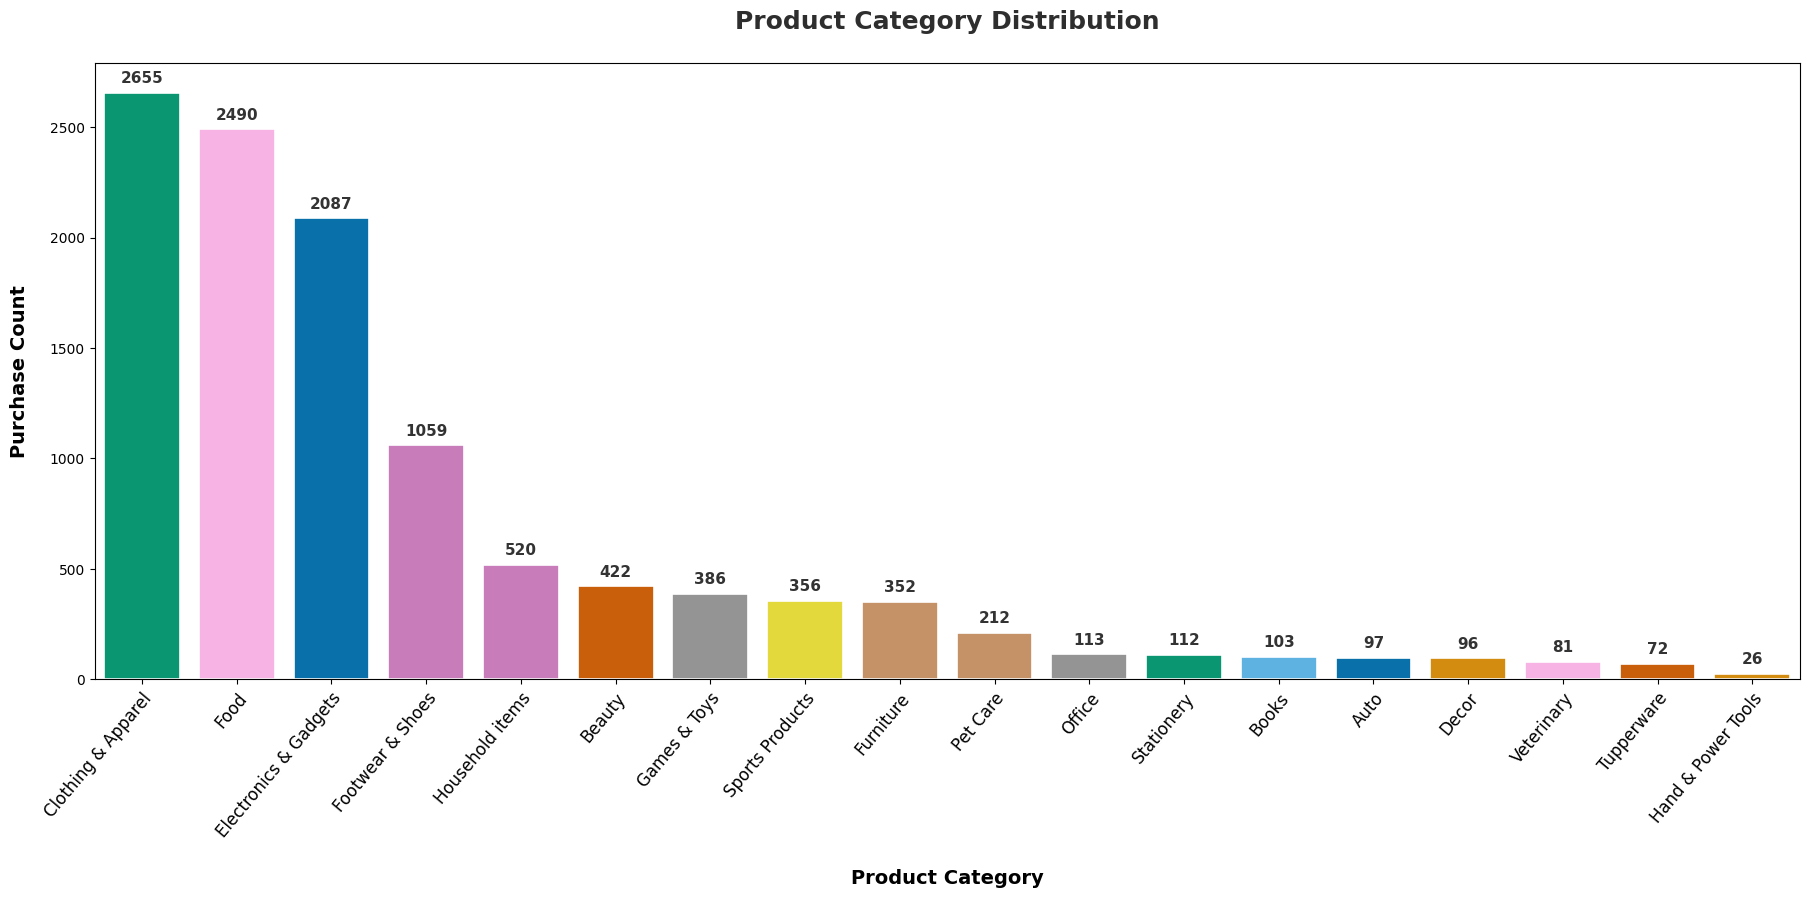

In [133]:
product_palette = sns.color_palette("colorblind", n_colors=len(df['Product_Category'].unique()))

plt.figure(figsize=(22, 8))
ax = sns.countplot(data=df, 
                   x='Product_Category',
                   order=df['Product_Category'].value_counts().index,
                   hue='Product_Category',
                   palette=product_palette,
                   saturation=0.9,
                   edgecolor='white',
                   linewidth=1.2,
                   dodge=False,
                   legend=False)

for bars in ax.containers:
    ax.bar_label(bars, 
                 label_type='edge',
                 fontsize=11,
                 padding=5,
                 color='#333333',
                 fontweight='semibold')

plt.xticks(rotation=50, 
           ha='right',
           rotation_mode='anchor',
           fontsize=12)

plt.title('Product Category Distribution', 
          fontsize=18, pad=25, fontweight='bold', color='#2e2e2e')
plt.xlabel('Product Category', fontsize=14, labelpad=20, fontweight='semibold')
plt.ylabel('Purchase Count', fontsize=14, labelpad=15, fontweight='semibold')




Text(0, 0.5, 'Sales Amount')

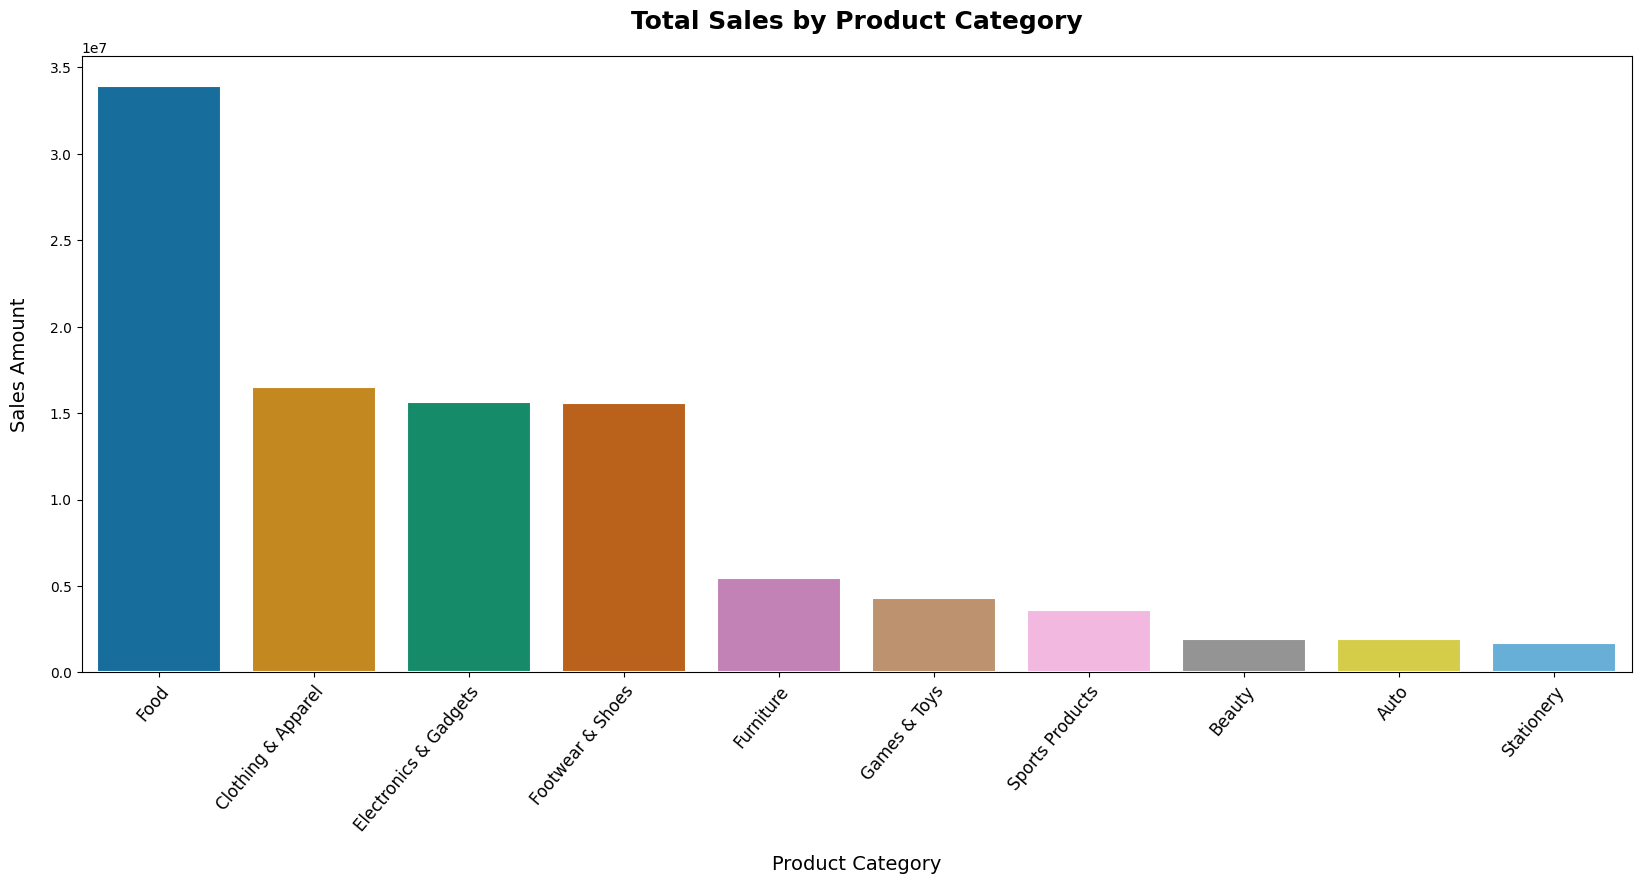

In [136]:
sales_state = df.groupby(['Product_Category'])[['Amount']].sum().sort_values(by='Amount', ascending=False).head(10)
plt.figure(figsize=(20, 8))
palette = sns.color_palette("colorblind", len(sales_state))
sns.barplot(
    data=sales_state , x='Product_Category', y='Amount',
    hue='Product_Category',
    palette=palette,
    edgecolor='white',
    linewidth=1.5
    )
plt.xticks(rotation=50,
           ha='right',
           rotation_mode='anchor',
           fontsize=12)
plt.title('Total Sales by Product Category', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('Product Category', fontsize=14, labelpad=15)
plt.ylabel('Sales Amount', fontsize=14, labelpad=15)



In [ ]:
'''
From the above analysis on Product Category, we can see that most of the sold products
are from the Food, Clothing and Electronics Category
'''

### Conclusion:
Married women age group 26-35 yrs from UP, Maharashtra and Karnataka working in IT,
Healthcare and Aviation are more likely buy products from Food, Clothing and Electronics Category